In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/Cleaned-Telco-data.csv')

In [3]:
df.head()

,zip code,latitude,longitude,gender,senior citizen,partner,dependents,tenure months,phone service,multiple lines,...,paperless billing,monthly charges,total charges,churn value,churn score,cltv,payment method_Bank transfer (automatic),payment method_Credit card (automatic),payment method_Electronic check,payment method_Mailed check
0,90003,33.964131,-118.272783,0,1,1,1,2,0,2,...,0,53.85,108.15,1,86,3239,0.0,0.0,0.0,1.0
1,90005,34.059281,-118.307420,1,1,1,0,2,0,2,...,0,70.70,151.65,1,67,2701,0.0,0.0,1.0,0.0
2,90006,34.048013,-118.293953,1,1,1,0,8,0,1,...,0,99.65,820.50,1,86,5372,0.0,0.0,1.0,0.0
3,90010,34.062125,-118.315709,1,1,0,0,28,0,1,...,0,104.80,3046.05,1,84,5003,0.0,0.0,1.0,0.0
4,90015,34.039224,-118.266293,0,1,1,0,49,0,1,...,0,103.70,5036.30,1,89,5340,1.0,0.0,0.0,0.0


In [4]:
df.drop(columns=['churn score', 'cltv'], axis=1, inplace=True)

In [5]:
x = df[[x for x in df.columns if x != 'churn value']]
y = df['churn value']

### train test split --

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [7]:
require_scaling = [x for x in df.columns if len(df[x].unique()) > 4]
print(require_scaling)

['zip code', 'latitude', 'longitude', 'tenure months', 'monthly charges', 'total charges']


In [8]:
x_train.isna().sum()

zip code                                    0
latitude                                    0
longitude                                   0
gender                                      0
senior citizen                              0
partner                                     0
dependents                                  0
tenure months                               0
phone service                               0
multiple lines                              0
internet service                            0
online security                             0
online backup                               0
device protection                           0
tech support                                0
streaming tv                                0
streaming movies                            0
contract                                    0
paperless billing                           0
monthly charges                             0
total charges                               0
payment method_Bank transfer (auto

Text(0.5, 1.0, 'Before scale data')

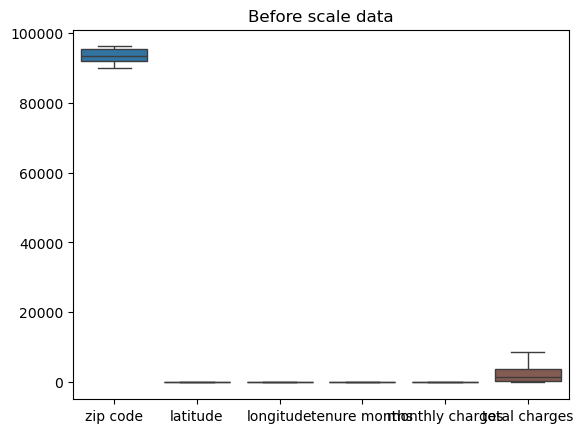

In [9]:
sns.boxplot(df[require_scaling])
plt.title("Before scale data")

### Scale the data--

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
x_train_scaled = scaler.fit_transform(x_train)

Text(0.5, 1.0, 'After scaling data')

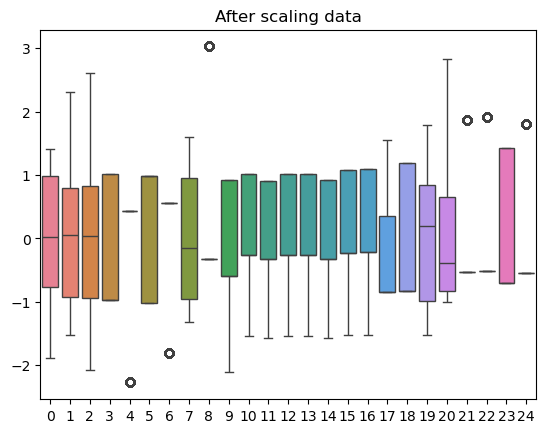

In [12]:
sns.boxplot(x_train_scaled)
plt.title("After scaling data")

In [13]:
x_test_scaled = scaler.transform(x_test)

In [14]:
### Base model Logistic Regression Implementation --

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
regression = LogisticRegression()

In [17]:
regression.fit(x_train_scaled, y_train)

LogisticRegression()

In [18]:
base_y_pred = regression.predict(x_test_scaled)

### Model Evaluation --

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
print("accuracy -", accuracy_score(y_test, base_y_pred))
print(confusion_matrix(y_test, base_y_pred))
print(classification_report(y_test, base_y_pred))

accuracy - 0.8080636002271436
[[1122  140]
 [ 198  301]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1262
           1       0.68      0.60      0.64       499

    accuracy                           0.81      1761
   macro avg       0.77      0.75      0.75      1761
weighted avg       0.80      0.81      0.80      1761



### Cross Validation & Hyperparameter Tuning --

##### GridSearchCV

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
param = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'penalty': ['l2'],
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio' : [0.001, 0.004, 0.006, 0.02, 0.1]
    }
]

In [23]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [24]:
grid = GridSearchCV(estimator=model, param_grid=param, cv=cv, scoring='accuracy', n_jobs=-1)

In [25]:
grid.fit(x_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                          'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                     'saga']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'l1_ratio': [0.001, 0.004, 0.006, 0.02, 0.1],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='accuracy')

In [26]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.8127590952094265


In [27]:
grid_y_pred = grid.predict(x_test_scaled)

In [28]:
print("accuracy -", accuracy_score(y_test, grid_y_pred))
print(confusion_matrix(y_test, grid_y_pred))
print(classification_report(y_test, grid_y_pred))

accuracy - 0.8052243043725156
[[1122  140]
 [ 203  296]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1262
           1       0.68      0.59      0.63       499

    accuracy                           0.81      1761
   macro avg       0.76      0.74      0.75      1761
weighted avg       0.80      0.81      0.80      1761



##### RandomSearchCV

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
model = LogisticRegression()

In [31]:
rand = RandomizedSearchCV(estimator=model, param_distributions=param, cv=cv, scoring='accuracy', n_jobs=-1)

In [32]:
rand.fit(x_train_scaled, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions=[{'C': [0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l1'],
                                         'solver': ['liblinear', 'saga']},
                                        {'C': [0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l2'],
                                         'solver': ['newton-cg', 'lbfgs',
                                                    'liblinear', 'sag',
                                                    'saga']},
                                        {'C': [0.01, 0.1, 1, 10, 100],
                                         'l1_ratio': [0.001, 0.004, 0.006, 0.02,
                                                      0.1],
                                         'penalty': ['elasticnet'],
                                         'solver': ['saga']}],
                   scoring='accuracy')

In [36]:
rand_y_pred = rand.predict(x_test_scaled)

In [34]:
print(rand.best_params_)
print(rand.best_score_)

{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.006, 'C': 0.1}
0.8125697012700325


In [37]:
print("accuracy -", accuracy_score(y_test, rand_y_pred))
print(confusion_matrix(y_test, rand_y_pred))
print(classification_report(y_test, rand_y_pred))

accuracy - 0.8057921635434412
[[1122  140]
 [ 202  297]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1262
           1       0.68      0.60      0.63       499

    accuracy                           0.81      1761
   macro avg       0.76      0.74      0.75      1761
weighted avg       0.80      0.81      0.80      1761

